# NB02: OTU Niche Breadth (Levins' B)

Computes prevalence-adjusted Levins' niche breadth for all 98,919 OTUs across 13 environment types.

**Inputs**:
- `arkinlab_microbeatlas.otu_counts_long` (260M rows) — via CLI Spark
- `arkinlab_microbeatlas.sample_metadata` (464K rows)
- `data/otu_taxonomy_parsed.csv` — taxonomy + nitrifier annotations

**Outputs**:
- `data/otu_env_matrix.csv` — sparse OTU × environment detection counts
- `data/env_totals.csv` — sample counts per environment (normalisation denominator)
- `data/otu_niche_breadth.csv` — per-OTU Levins' B and metadata
- `data/otu_env_prevalence_wide.csv` — wide-format prevalence matrix (for ML)

**Formula**: Prevalence-adjusted Levins' B corrects for unequal sampling effort.  
p_i = detections_in_env_i / total_samples_in_env_i  
q_i = p_i / Σ(p_j)  
B = 1 / Σ(q_i²)  
B_std = (B − 1) / (n_envs − 1)  →  [0 = strict specialist, 1 = perfect generalist]

In [1]:
from berdl_notebook_utils.setup_spark_session import get_spark_session
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

DATA = Path('../data')
FIGURES = Path('../figures')
FIGURES.mkdir(exist_ok=True)

## 1. Spark: environment totals + OTU × environment detection matrix

In [2]:
spark = get_spark_session()

env_totals = spark.sql("""
    SELECT Env_Level_1, COUNT(*) AS n_total_samples
    FROM arkinlab_microbeatlas.sample_metadata
    WHERE Env_Level_1 IS NOT NULL
    GROUP BY Env_Level_1
""").toPandas()
env_totals.to_csv(DATA / 'env_totals.csv', index=False)
print(env_totals.sort_values('n_total_samples', ascending=False).to_string())

     Env_Level_1  n_total_samples
5        aquatic           221299
4           soil            80991
7          plant            77237
2          field            28553
11        forest            18278
10  agricultural            17911
1           farm             8039
9         desert             3212
12          leaf             2938
0          paddy             2831
6       peatland             1868
8          shrub              717
3         flower               98


In [3]:
# 260M-row join — broadcast sample_metadata, group by OTU × environment
# Runtime: ~50s on-cluster
otu_env = spark.sql("""
    SELECT
        c.otu_id,
        s.Env_Level_1,
        COUNT(DISTINCT c.sample_id) AS n_samples_detected
    FROM arkinlab_microbeatlas.otu_counts_long c
    JOIN arkinlab_microbeatlas.sample_metadata s ON c.sample_id = s.sample_id
    WHERE s.Env_Level_1 IS NOT NULL
    GROUP BY c.otu_id, s.Env_Level_1
""").toPandas()

otu_env.to_csv(DATA / 'otu_env_matrix.csv', index=False)
print(f"Rows: {len(otu_env):,}  |  OTUs: {otu_env['otu_id'].nunique():,}")
spark.stop()

Rows: 626,711  |  OTUs: 98,919


## 2. Levins' niche breadth computation

In [4]:
# Load pre-computed data if Spark cells already run
env_mat    = pd.read_csv(DATA / 'otu_env_matrix.csv')
env_totals = pd.read_csv(DATA / 'env_totals.csv').set_index('Env_Level_1')['n_total_samples'].to_dict()
otu_tax    = pd.read_csv(DATA / 'otu_taxonomy_parsed.csv',
                         usecols=['otu_id','kingdom','phylum','genus',
                                  'nitrifier_role','is_organellar','is_unmapped',
                                  'n_cells_by_counts','total_counts'])

env_mat['prevalence'] = env_mat['n_samples_detected'] / env_mat['Env_Level_1'].map(env_totals)

In [5]:
def levins_b(grp):
    p = grp['prevalence'].values
    q = p / p.sum()
    B = 1.0 / (q ** 2).sum()
    n = len(p)
    return pd.Series({
        'n_envs_detected':  n,
        'levins_B':         B,
        'levins_B_std':     (B - 1) / (n - 1) if n > 1 else 0.0,
        'dominant_env':     grp.loc[grp['prevalence'].idxmax(), 'Env_Level_1'],
        'max_prevalence':   p.max(),
        'mean_prevalence':  p.mean(),
        'total_detections': grp['n_samples_detected'].sum(),
    })

niche = env_mat.groupby('otu_id').apply(levins_b, include_groups=False).reset_index()
niche = niche.merge(otu_tax, on='otu_id', how='left')
niche.to_csv(DATA / 'otu_niche_breadth.csv', index=False)
print(f"Saved otu_niche_breadth.csv  ({len(niche):,} OTUs)")
niche['levins_B_std'].describe().round(3)

Saved otu_niche_breadth.csv  (98,919 OTUs)


count    98919.000
mean         0.333
std          0.255
min          0.000
25%          0.104
50%          0.301
75%          0.538
max          1.000
Name: levins_B_std, dtype: float64

In [6]:
# Wide prevalence matrix for NB06 ML
wide = env_mat.pivot(index='otu_id', columns='Env_Level_1', values='prevalence').fillna(0)
wide.reset_index().to_csv(DATA / 'otu_env_prevalence_wide.csv', index=False)
print(f"Wide matrix: {wide.shape[0]:,} OTUs × {wide.shape[1]} environments")

Wide matrix: 98,919 OTUs × 13 environments


## 3. Niche breadth distribution

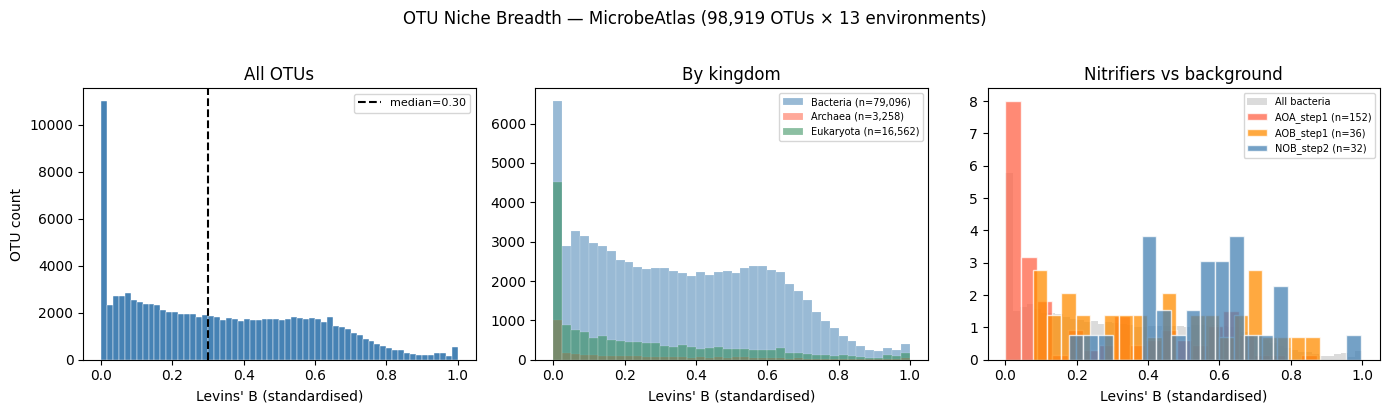

Saved figures/niche_breadth_distribution.png


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# 3a — Overall distribution
clean = niche[~niche['is_unmapped'].fillna(False)]
axes[0].hist(clean['levins_B_std'], bins=60, color='steelblue', edgecolor='white', linewidth=0.3)
axes[0].axvline(clean['levins_B_std'].median(), color='k', ls='--', label=f"median={clean['levins_B_std'].median():.2f}")
axes[0].set_xlabel("Levins' B (standardised)")
axes[0].set_ylabel("OTU count")
axes[0].set_title("All OTUs")
axes[0].legend(fontsize=8)

# 3b — By kingdom
kd_order = ['Bacteria', 'Archaea', 'Eukaryota']
kd_colors = {'Bacteria': 'steelblue', 'Archaea': 'tomato', 'Eukaryota': 'seagreen'}
for kd in kd_order:
    sub = clean[clean['kingdom'] == kd]['levins_B_std']
    axes[1].hist(sub, bins=40, alpha=0.55, label=f"{kd} (n={len(sub):,})",
                 color=kd_colors[kd], edgecolor='white', linewidth=0.2)
axes[1].set_xlabel("Levins' B (standardised)")
axes[1].set_title("By kingdom")
axes[1].legend(fontsize=7)

# 3c — Nitrifier roles vs background
bg = clean[clean['nitrifier_role'].isna()]['levins_B_std']
axes[2].hist(bg, bins=50, color='lightgray', label='All bacteria', density=True, alpha=0.8)
nit_colors = {'AOA_step1': 'tomato', 'AOB_step1': 'darkorange', 'NOB_step2': 'steelblue'}
for role, col in nit_colors.items():
    vals = clean[clean['nitrifier_role'] == role]['levins_B_std']
    axes[2].hist(vals, bins=20, color=col, alpha=0.75, label=f"{role} (n={len(vals)})",
                 density=True, edgecolor='white')
axes[2].set_xlabel("Levins' B (standardised)")
axes[2].set_title("Nitrifiers vs background")
axes[2].legend(fontsize=7)

plt.suptitle("OTU Niche Breadth — MicrobeAtlas (98,919 OTUs × 13 environments)", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES / 'niche_breadth_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved figures/niche_breadth_distribution.png")

## 4. Nitrifier case study

In [11]:
nit = niche[niche['nitrifier_role'].notna()].sort_values('n_cells_by_counts', ascending=False)
print("Nitrifier group means:")
print(nit.groupby('nitrifier_role')[['levins_B_std','n_envs_detected','max_prevalence']]
      .mean(numeric_only=True).round(3))
print("\nTop 10 nitrifier OTUs:")
print(nit.head(10)[['otu_id','genus','nitrifier_role','levins_B_std',
                     'n_envs_detected','dominant_env','n_cells_by_counts']].to_string())

Nitrifier group means:
                levins_B_std  n_envs_detected  max_prevalence
nitrifier_role                                               
AOA_step1              0.227            5.342           0.026
AOB_step1              0.431            7.917           0.043
NOB_step2              0.558            9.719           0.105

Top 10 nitrifier OTUs:
         otu_id           genus nitrifier_role  levins_B_std  n_envs_detected  dominant_env  n_cells_by_counts
17168   97_1749    Nitrosospira      AOB_step1      0.698109               12  agricultural             132528
89282  97_89870  Nitrososphaera      AOA_step1      0.772803               13  agricultural             112756
45258   97_4531      Nitrospira      NOB_step2      0.593228               13  agricultural             105071
66175   97_6633      Nitrospira      NOB_step2      0.775359               12         paddy              98476
82779   97_8323      Nitrospira      NOB_step2      0.575604               12         pa

## 5. Dominant environment distribution

In [12]:
dom = (clean.groupby('dominant_env')
       .agg(n_otus=('otu_id','count'),
            mean_B_std=('levins_B_std','mean'),
            median_B_std=('levins_B_std','median'))
       .join(pd.Series(env_totals, name='n_total_samples'))
       .sort_values('n_otus', ascending=False)
       .reset_index())
dom['otus_per_1k_samples'] = dom['n_otus'] / dom['n_total_samples'] * 1000
print(dom.to_string())

    dominant_env  n_otus  mean_B_std  median_B_std  n_total_samples  otus_per_1k_samples
0        aquatic   40353    0.221188      0.138082           221299           182.346057
1           farm   13592    0.319095      0.286171             8039          1690.757557
2   agricultural    7511    0.524368      0.555018            17911           419.351237
3          paddy    7013    0.377664      0.355951             2831          2477.216531
4          shrub    5088    0.319339      0.289667              717          7096.234310
5           soil    5001    0.537722      0.586939            80991            61.747602
6         desert    4751    0.410563      0.421293             3212          1479.140722
7          field    3872    0.511535      0.538883            28553           135.607467
8       peatland    3784    0.342955      0.321015             1868          2025.695931
9         forest    3110    0.397713      0.395430            18278           170.149907
10         plant    2